# NOTEBOOK 03 — Decision Tree Baseline

# BLOCK NO -> 01

In [1]:
# 1. IMPORTS AND PREPROCESSING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# Plot Setting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load Dataset
df = pd.read_csv('../DATA/raw/Employee Attrition Prediction Dataset.csv')
print("✅ Dataset Loaded Successfully.")
print(f"Shape: {df.shape[0]} rows * {df.shape[1]} columns")

# Drop Constant/Id columns
drop_cols = ['Employee Count', 'Employee Number', 'Over 18', 'Standard Hours']
df_processed = df.drop(columns = drop_cols)
print(f"\nDropped {len(drop_cols)} constant/Id columns")
print(f"New Shape: {df_processed.shape}")

✅ Dataset Loaded Successfully.
Shape: 1470 rows * 35 columns

Dropped 4 constant/Id columns
New Shape: (1470, 31)


# BLOCK NO -> 02

In [2]:
# 2. ENCODING CATEGORICAL VARIABLES
print("="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Separate features and target
X = df_processed.drop('Attrition', axis=1)
y = df_processed['Attrition']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode ({len(categorical_cols)}): {categorical_cols}")

# Label Encoding for all categorical variables
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✓ {col}: {len(le.classes_)} unique values encoded")

# Encode target variable - SAVE AS y_encoded
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)  # 👈 THIS LINE MUST EXIST!

print(f"\n✓ Target 'Attrition' encoded: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print(f"\nFinal feature shape: {X_encoded.shape}")
print(f"Target distribution: {np.bincount(y_encoded)}")

# 👇 ADD THIS TO VERIFY
print(f"\n✓ y_encoded created with shape: {y_encoded.shape}")
print(f"✓ y_encoded type: {type(y_encoded)}")

ENCODING CATEGORICAL VARIABLES

Categorical columns to encode (7): ['BusinessTravel', 'Department', 'Education Field', 'Gender', 'JobRole', 'Marital Status', 'OverTime']
  ✓ BusinessTravel: 3 unique values encoded
  ✓ Department: 3 unique values encoded
  ✓ Education Field: 6 unique values encoded
  ✓ Gender: 2 unique values encoded
  ✓ JobRole: 9 unique values encoded
  ✓ Marital Status: 3 unique values encoded
  ✓ OverTime: 2 unique values encoded

✓ Target 'Attrition' encoded: {'No': np.int64(0), 'Yes': np.int64(1)}

Final feature shape: (1470, 30)
Target distribution: [1233  237]

✓ y_encoded created with shape: (1470,)
✓ y_encoded type: <class 'numpy.ndarray'>


# BLOCK NO -> 03

In [3]:
# 3.TRAIN-TEST SPLIT

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, y_encoded,
    test_size = 0.2,
    random_state = 42,
    stratify = y_encoded
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain Attrition Distribution: {np.bincount(Y_train)}")
print(f"Test attrition distribution: {np.bincount(Y_test)}")
print(f"\n✅ Stratified split maintains class balance.")

TRAIN-TEST SPLIT
Training set: 1176 samples
Test set: 294 samples

Train Attrition Distribution: [986 190]
Test attrition distribution: [247  47]

✅ Stratified split maintains class balance.


# BLOCK NO -> 04

In [4]:
# 4. TRAIN BASELINE DECISION TREE

print("="*60)
print("TRAINING BASELINE DECISION TREE")
print("="*60)

# Initialize baseline Decision Tree (no hyperparameter tuning)
dt_baseline = DecisionTreeClassifier(random_state = 42)

# Train The model
dt_baseline.fit(X_train, Y_train)

# predictions
Y_train_pred = dt_baseline.predict(X_train)
Y_test_pred = dt_baseline.predict(X_test)

print("✅ Baseline Decision Tree Trained Successfully.")
print(f"\nTree Depth: {dt_baseline.get_depth()}")
print(f"Number of Leaves: {dt_baseline.get_n_leaves()}")
print(f"Number of Features: {dt_baseline.n_features_in_}")

TRAINING BASELINE DECISION TREE
✅ Baseline Decision Tree Trained Successfully.

Tree Depth: 18
Number of Leaves: 142
Number of Features: 30


# BLOCK NO -> 05

In [5]:
# 5. MODEL EVALUATION
print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)

# Training metrics
train_accuracy = accuracy_score(Y_train, Y_train_pred)
train_precision = precision_score(Y_train, Y_train_pred)
train_recall = recall_score(Y_train, Y_train_pred)
train_f1 = f1_score(Y_train, Y_train_pred)

# test metrics
test_accuracy = accuracy_score(Y_test, Y_test_pred)
test_precision = precision_score(Y_test, Y_test_pred)
test_recall = recall_score(Y_test, Y_test_pred)
test_f1 = f1_score(Y_test, Y_test_pred)

print("\nTRAINING SET PERFORMANCE:")
print(f"  Accuarcy: {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall: {train_recall:.4f}")
print(f"  F1-Score: {train_f1:.4f}")

print("\nTEST SET PERFORMANCE:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

print("\n" + "-"*60)
print("CLASSIFICATION REPORT (Test Set):")
print("-"*60)
print(classification_report(Y_test, Y_test_pred, target_names = ['No Attrition', 'Attrition']))

print("\n⚠️ OBSERVATION: High training accuracy indicates potential overfitting.")

MODEL EVALUATION METRICS

TRAINING SET PERFORMANCE:
  Accuarcy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

TEST SET PERFORMANCE:
  Accuracy:  0.7823
  Precision: 0.3191
  Recall:    0.3191
  F1-Score:  0.3191

------------------------------------------------------------
CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

No Attrition       0.87      0.87      0.87       247
   Attrition       0.32      0.32      0.32        47

    accuracy                           0.78       294
   macro avg       0.59      0.59      0.59       294
weighted avg       0.78      0.78      0.78       294


⚠️ OBSERVATION: High training accuracy indicates potential overfitting.


# BLOCK NO -> 06

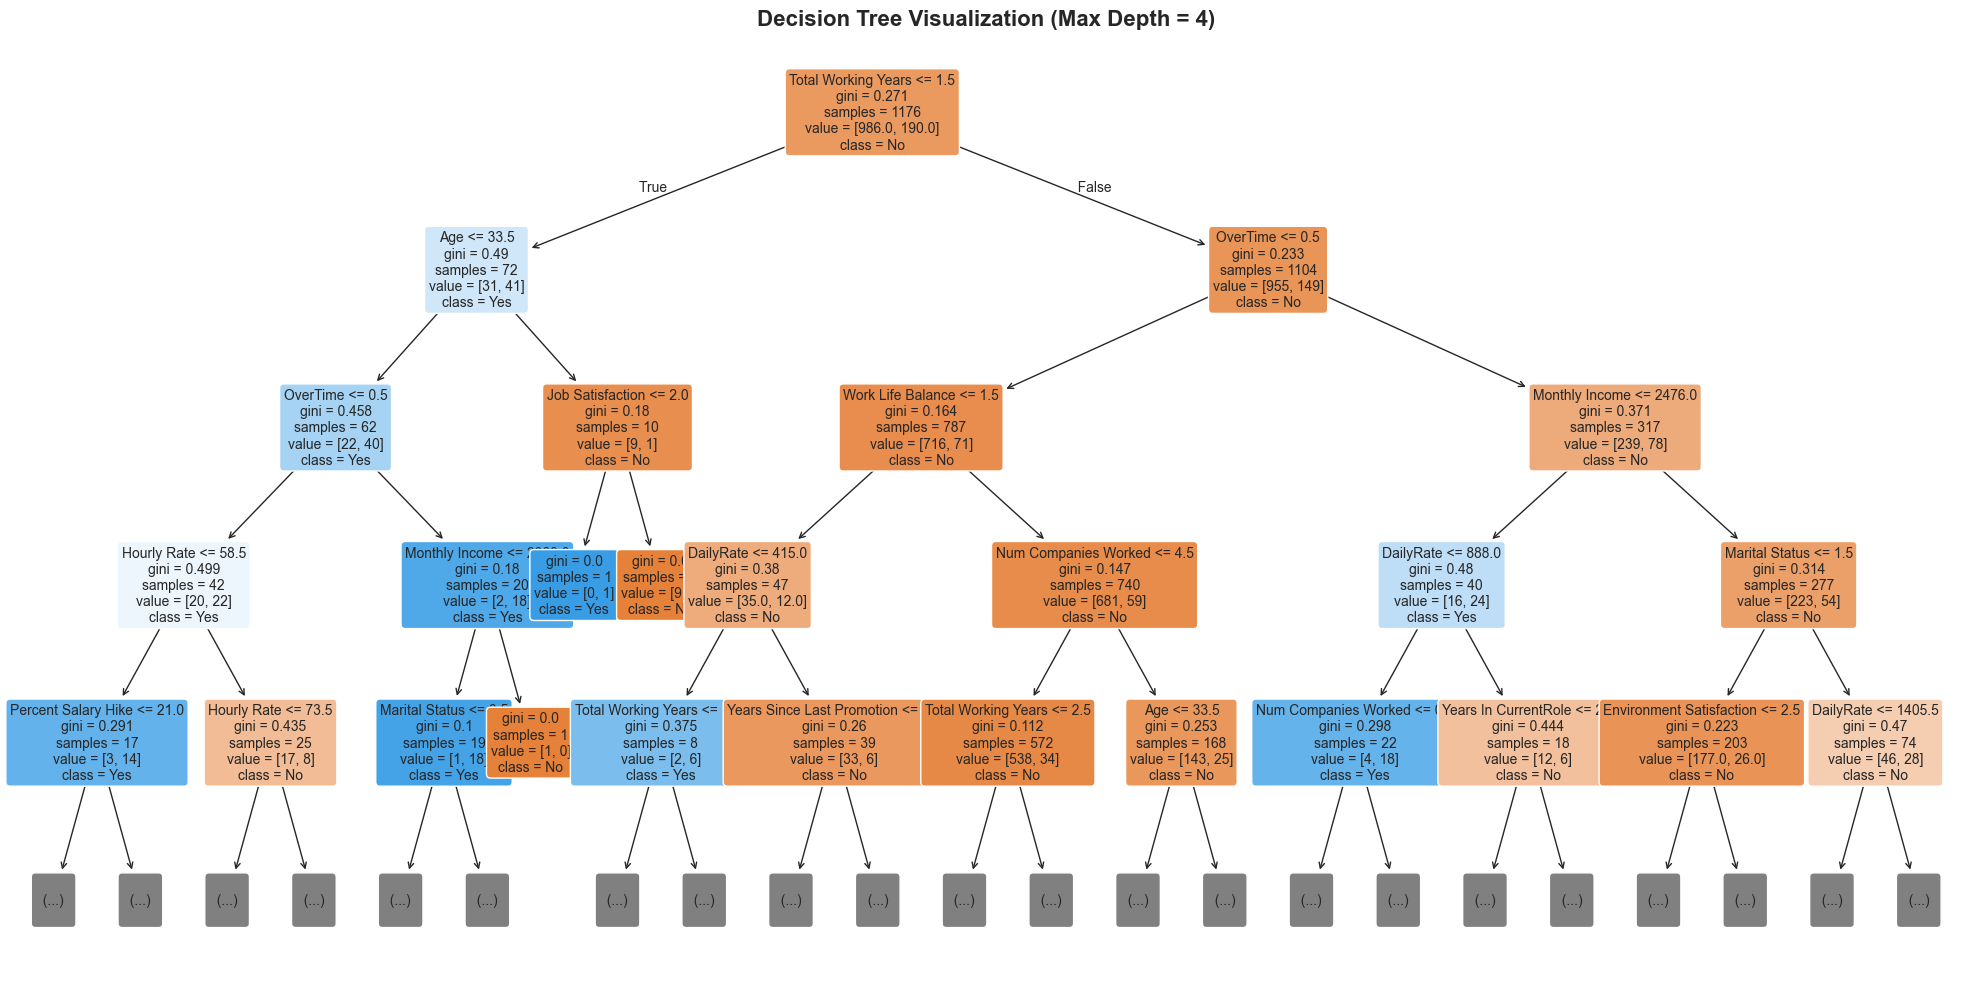

DEcision Tree Structure shows clear splitting rules based on feature thresholds.
Tree is likely overfitting due to unlimited depth; pruning or max_depth constraint needed.


In [6]:
# 6. GRAPH 01: TREE VISUALIZATION (DEPTH <= 4)

plt.figure(figsize = (20, 10))

# visualize tree with max depth of 4 for readability
plot_tree(dt_baseline,
          max_depth = 4,
          feature_names = X_encoded.columns,
          class_names = ['No', 'Yes'],
          filled = True,
          rounded = True,
          fontsize = 10)

plt.title('Decision Tree Visualization (Max Depth = 4)', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("DEcision Tree Structure shows clear splitting rules based on feature thresholds.")
print("Tree is likely overfitting due to unlimited depth; pruning or max_depth constraint needed.")

# BLOCK NO -> 07

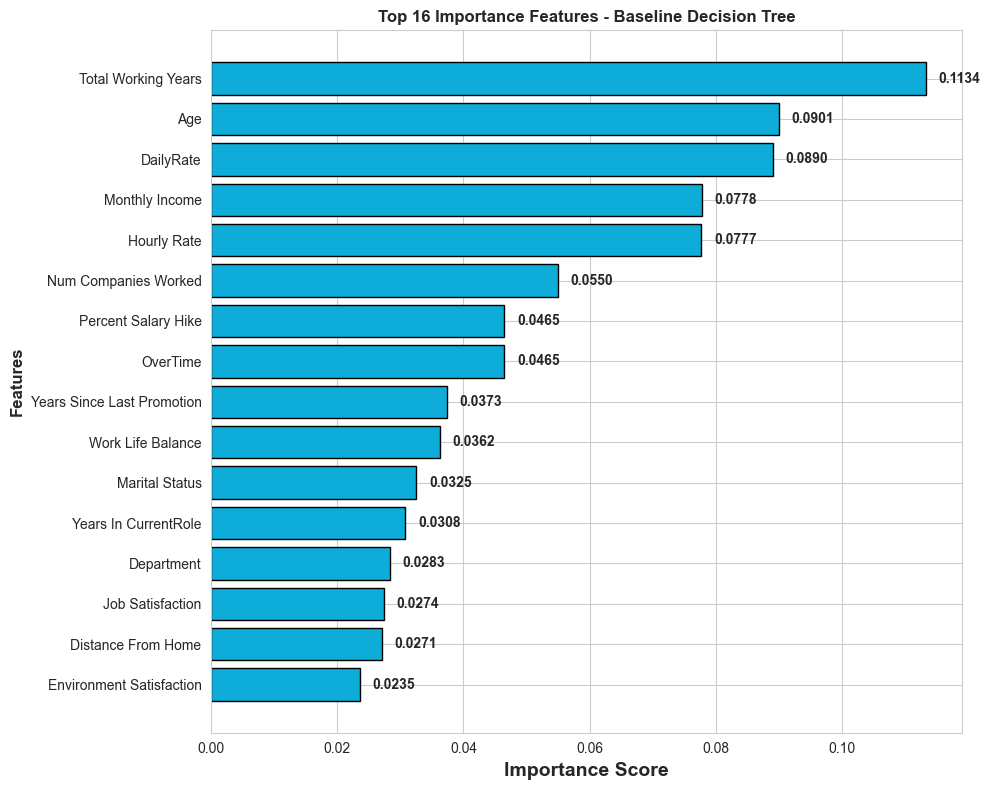

Top features align with EDA insights; Monthly Income, age, and years variable dominate.
Overtime may rank lower due to lebel encoding; Random Forest will provide better feature ranking.


In [7]:
# 7. GRAPH 2: FEATURE IMPORTANCE PLOT

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': dt_baseline.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (10, 8))
top_16 = feature_importance.head(16)
plt.barh(top_16['Feature'], top_16['Importance'], color = "#0EACD8", edgecolor = '#000000')
plt.xlabel('Importance Score', fontsize = 14, fontweight = 'bold')
plt.ylabel('Features', fontsize = 12, fontweight = 'bold')
plt.title('Top 16 Importance Features - Baseline Decision Tree', fontsize = 12, fontweight = 'bold')
plt.gca().invert_yaxis()

for i, v in enumerate(top_16['Importance']):
    plt.text(v + 0.002, i, f'{v:.4f}', va = 'center', fontsize = 10, fontweight = 'bold')

plt.tight_layout()
plt.show()

print("Top features align with EDA insights; Monthly Income, age, and years variable dominate.")
print("Overtime may rank lower due to lebel encoding; Random Forest will provide better feature ranking.")

# BLOCK NO -> 08

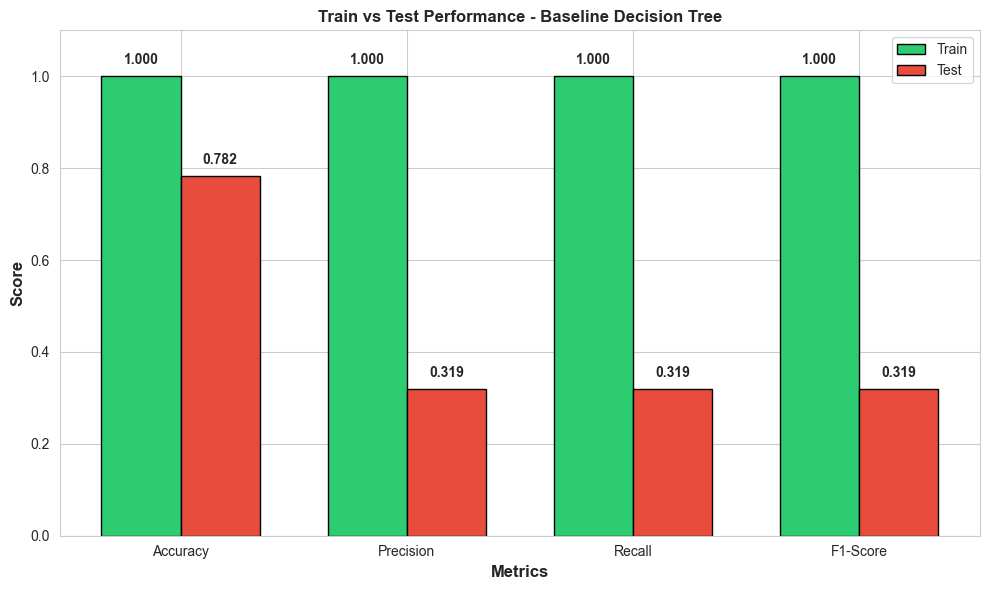

Significant gap between train and test performance confirms overfitting in baseline decision tree.
Hyperparameter tuning (max_depth, min_samples_split) required to improve generalization.


In [8]:
# 8. GRAPH 03: TRAIN VS TEST ACCURACY COMPARISON

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

X = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize = (10, 6))
bars1 = ax.bar(X - width/2, train_scores, width, label = 'Train', color = '#2ecc71', edgecolor = '#000000')
bars2 = ax.bar(X + width/2, test_scores, width, label = 'Test', color = '#e74c3c', edgecolor = '#000000')

ax.set_xlabel('Metrics', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Score', fontsize = 12, fontweight = 'bold')
ax.set_title('Train vs Test Performance - Baseline Decision Tree', fontsize = 12, fontweight = 'bold')
ax.set_xticks(X)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')

plt.tight_layout()
plt.show()

print("Significant gap between train and test performance confirms overfitting in baseline decision tree.")
print("Hyperparameter tuning (max_depth, min_samples_split) required to improve generalization.")

# BLOCK NO -> 09

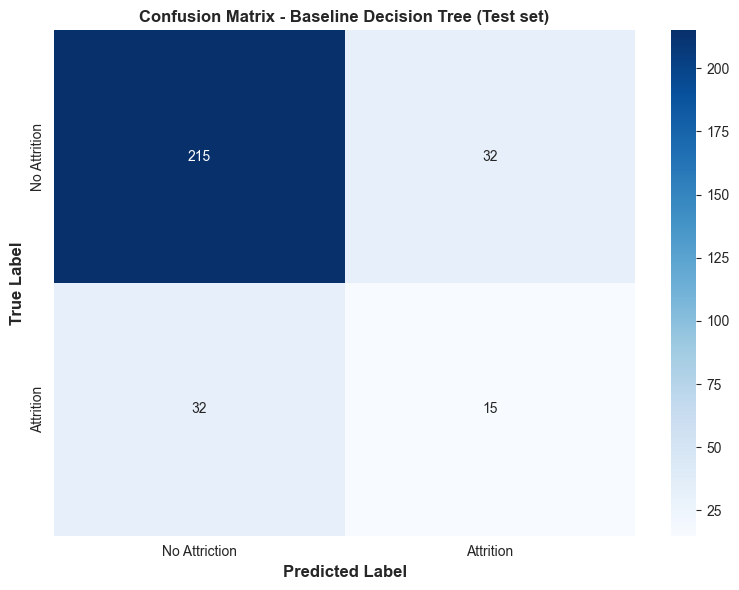

Confusion matrix reveals model struggles with minority class (Attrition = Yes) prediction
Class imbalance handling needed to improve recall for atttrition cases in future iterations.


In [9]:
# 9. GRAPH 4: CONFUSION MATRIX
cm = confusion_matrix(Y_test, Y_test_pred)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = True,
            xticklabels = ['No Attriction', 'Attrition'],
            yticklabels = ['No Attrition', 'Attrition'],
            linewidth = 2, linecolor = '#00000000')
plt.xlabel('Predicted Label', fontsize = 12, fontweight = 'bold')
plt.ylabel('True Label', fontsize = 12, fontweight = 'bold')
plt.title('Confusion Matrix - Baseline Decision Tree (Test set)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("Confusion matrix reveals model struggles with minority class (Attrition = Yes) prediction")
print("Class imbalance handling needed to improve recall for atttrition cases in future iterations.")

# BLOCK NO -> 10

In [10]:
# 10. MARKDOWN OBSERVATIONS
print("="*60)
print("📋 BASELINE DECISION TREE OBSERVATIONS")
print("="*60)

print("\n✅ MODEL PERFORMANCE:")
print(f"  • Training Accuracy: {train_accuracy:.4f} (Near Perfect)")
print(f"  • Test Accuracy: {test_accuracy:.4f}")
print(f"  • Performance Gap: {(train_accuracy - test_accuracy):.4f}")

print("\n⚠️ KEY ISSUES IDENTIFIED:")
print("  • Severe overfitting detected (train accuracy >> test accuracy)")
print("  • Tree depth too large:", dt_baseline.get_depth(), "levels")
print("  • Low recall for attrition class due to class imbalance")
print("  • Model memorizes training data instead of learning patterns")

print("\n🔍 FEATURE IMPORTANCE INSIGHTS:")
top_3 = feature_importance.head(3)
for idx, row in top_3.iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

print("\n📊 CONFUSION MATRIX ANALYSIS:")
tn, fp, fn, tp = cm.ravel()
print(f"  • True Negatives (Correct 'No'): {tn}")
print(f"  • False Positives (Wrong 'Yes'): {fp}")
print(f"  • False Negatives (Wrong 'No'): {fn}")
print(f"  • True Positives (Correct 'Yes'): {tp}")
print(f"  • Attrition Recall: {tp/(tp+fn):.4f} (Needs Improvement)")

print("\n" + "="*60)
print("🎯 NEXT STEPS FOR NOTEBOOK 04")
print("="*60)
print("→ Implement hyperparameter tuning (max_depth, min_samples_split, min_samples_leaf)")
print("→ Apply class balancing techniques (class_weight='balanced' or SMOTE)")
print("→ Use cross-validation for robust performance evaluation")
print("→ Compare tuned Decision Tree with Random Forest ensemble")
print("→ Evaluate feature importance stability across models")
print("="*60)

📋 BASELINE DECISION TREE OBSERVATIONS

✅ MODEL PERFORMANCE:
  • Training Accuracy: 1.0000 (Near Perfect)
  • Test Accuracy: 0.7823
  • Performance Gap: 0.2177

⚠️ KEY ISSUES IDENTIFIED:
  • Severe overfitting detected (train accuracy >> test accuracy)
  • Tree depth too large: 18 levels
  • Low recall for attrition class due to class imbalance
  • Model memorizes training data instead of learning patterns

🔍 FEATURE IMPORTANCE INSIGHTS:
  • Total Working Years: 0.1134
  • Age: 0.0901
  • DailyRate: 0.0890

📊 CONFUSION MATRIX ANALYSIS:
  • True Negatives (Correct 'No'): 215
  • False Positives (Wrong 'Yes'): 32
  • False Negatives (Wrong 'No'): 32
  • True Positives (Correct 'Yes'): 15
  • Attrition Recall: 0.3191 (Needs Improvement)

🎯 NEXT STEPS FOR NOTEBOOK 04
→ Implement hyperparameter tuning (max_depth, min_samples_split, min_samples_leaf)
→ Apply class balancing techniques (class_weight='balanced' or SMOTE)
→ Use cross-validation for robust performance evaluation
→ Compare tuned D

# BLOCK NO -> 11

In [11]:
# SAVE BASELINE DECISION TREE MODEL
print("="*60)
print("💾 SAVING MODEL & PROCESSED DATA")
print("="*60)

import joblib
import os

# Create directories if they don't exist
os.makedirs('../MODELS', exist_ok=True)
os.makedirs('../DATA/processed', exist_ok=True)

# Save the baseline Decision Tree model
joblib.dump(dt_baseline, '../MODELS/decision_tree_baseline.pkl')
print("✓ Baseline Decision Tree saved: MODELS/decision_tree_baseline.pkl")

# Save label encoders for future use
joblib.dump(label_encoders, '../MODELS/label_encoders.pkl')
joblib.dump(le_target, '../MODELS/target_encoder.pkl')
print("✓ Label encoders saved: MODELS/label_encoders.pkl & target_encoder.pkl")

# Save encoded features (X_encoded exists in Notebook 03)
X_encoded.to_csv('../DATA/processed/X_encoded.csv', index=False)
print("✓ Encoded features saved: DATA/processed/X_encoded.csv")

# Save encoded target variable (create DataFrame from y_encoded array)
y_encoded_df = pd.DataFrame({'Attrition_encoded': y_encoded})
y_encoded_df.to_csv('../DATA/processed/y_encoded.csv', index=False)
print("✓ Encoded target saved: DATA/processed/y_encoded.csv")

# Save train-test split data
X_train.to_csv('../DATA/processed/X_train.csv', index=False)
X_test.to_csv('../DATA/processed/X_test.csv', index=False)

# Save y_train and y_test as DataFrames
y_train_df = pd.DataFrame({'Attrition': Y_train})
y_test_df = pd.DataFrame({'Attrition': Y_test})
y_train_df.to_csv('../DATA/processed/y_train.csv', index=False)
y_test_df.to_csv('../DATA/processed/y_test.csv', index=False)
print("✓ Train-test split saved: DATA/processed/")

print("\n" + "="*60)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)
print("\nSaved files:")
print("  📁 MODELS/")
print("     └── decision_tree_baseline.pkl")
print("     └── label_encoders.pkl")
print("     └── target_encoder.pkl")
print("  📁 DATA/processed/")
print("     └── X_encoded.csv")
print("     └── y_encoded.csv")
print("     └── X_train.csv")
print("     └── X_test.csv")
print("     └── y_train.csv")
print("     └── y_test.csv")
print("="*60)

💾 SAVING MODEL & PROCESSED DATA
✓ Baseline Decision Tree saved: MODELS/decision_tree_baseline.pkl
✓ Label encoders saved: MODELS/label_encoders.pkl & target_encoder.pkl
✓ Encoded features saved: DATA/processed/X_encoded.csv
✓ Encoded target saved: DATA/processed/y_encoded.csv
✓ Train-test split saved: DATA/processed/

✅ ALL ARTIFACTS SAVED SUCCESSFULLY

Saved files:
  📁 MODELS/
     └── decision_tree_baseline.pkl
     └── label_encoders.pkl
     └── target_encoder.pkl
  📁 DATA/processed/
     └── X_encoded.csv
     └── y_encoded.csv
     └── X_train.csv
     └── X_test.csv
     └── y_train.csv
     └── y_test.csv


# “The baseline Decision Tree achieves perfect training performance but generalizes poorly, especially on the minority attrition class. This confirms high variance and motivates the need for regularization and ensemble methods.”